In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from matplotlib.ticker import MaxNLocator


In [20]:
scen1 = pd.read_csv('scenario1.csv')
scen2 = pd.read_csv('scenario2.csv')
scen3 = pd.read_csv('scenario3.csv')


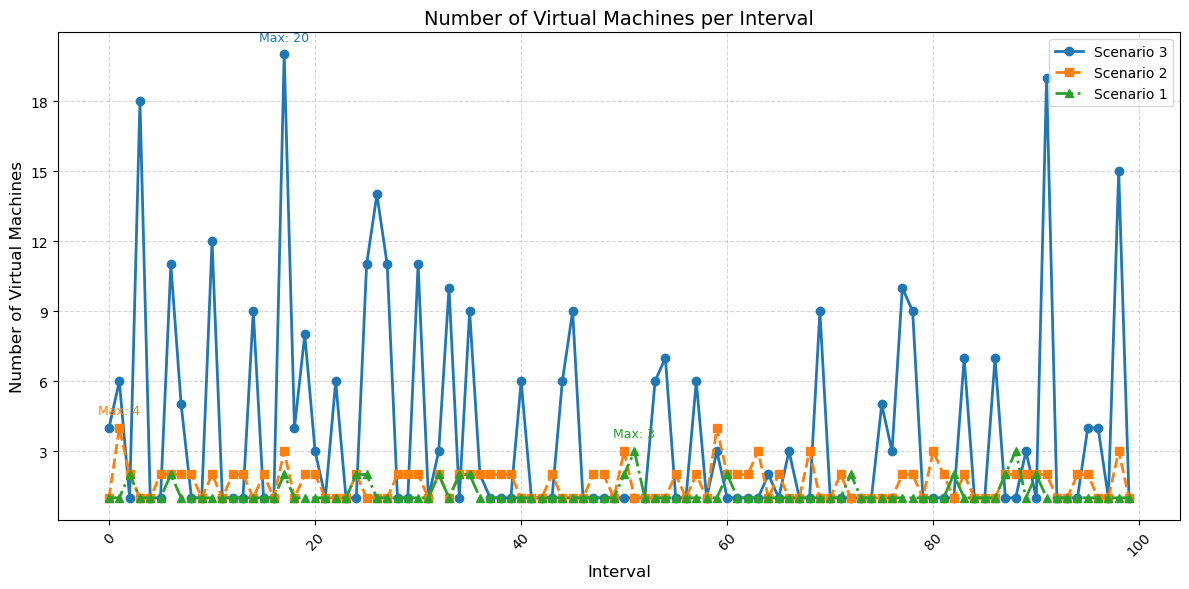

In [36]:
# plot number of virtual machines per interval per scenario
# create a dataframe with the number of VMs per interval
def plot_vms_per_interval(scenarios, labels):
    plt.figure(figsize=(12, 6))

    linestyles = ['-', '--', '-.', ':']
    markers = ['o', 's', '^', 'D', 'x', '*']
    colors = cm.tab10.colors  # Up to 10 nice distinct colors

    for i, (scenario, label) in enumerate(zip(scenarios, labels)):
        vm_counts = scenario.groupby('Interval')['CreationID'].count()
        intervals = vm_counts.index[:100]
        values = vm_counts.values[:100]
        plt.plot(intervals, values,
                 label=label,
                 color=colors[i % len(colors)],
                 linestyle=linestyles[i % len(linestyles)],
                 marker=markers[i % len(markers)],
                 markersize=6,
                 linewidth=2)

        # Optional: Annotate peak
        max_idx = np.argmax(values)
        plt.annotate(f'Max: {values[max_idx]}',
                     (intervals[max_idx], values[max_idx]),
                     textcoords="offset points",
                     xytext=(0,10),
                     ha='center',
                     fontsize=9,
                     color=colors[i % len(colors)])

    plt.title('Number of Virtual Machines per Interval', fontsize=14)
    plt.xlabel('Interval', fontsize=12)
    plt.ylabel('Number of Virtual Machines', fontsize=12)
    plt.xticks(rotation=45)
    plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

plot_vms_per_interval([scen3, scen2, scen1], ['Scenario 3', 'Scenario 2', 'Scenario 1'])

In [11]:
vm_counts = scen1.groupby('Interval')['CreationID'].count()